# 🌾 Global Crop Production Analysis (2000-2023)
**Data Source:** FAOSTAT (Food and Agriculture Organization)

**Analysis Goals:**
1. Identify top producing countries for major crops
2. Analyze production trends over 23 years
3. Compare crop specialization by region
4. Create visualization dashboard

**Author:** [Brandon Mamhova]
**Date:** [12/03/2026]

In [17]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('default')
sns.set_theme()
sns.set_palette("husl")

# Load the data
file_path = Path.home() / 'Desktop' / 'agriculture-data-analytics-project' / 'crop_production_FAOSTAT.csv'
df = pd.read_csv(file_path)

# Rename columns for easier use
df = df.rename(columns={
    'Area': 'Country',
    'Item': 'Crop',
    'Value': 'Production'
})

print("✅ Data loaded and prepared!")
print(f"📊 Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"🌍 Countries: {df['Country'].nunique()}")
print(f"🌽 Crops: {df['Crop'].nunique()}")
print(f"📅 Years: {df['Year'].min()} to {df['Year'].max()}")

✅ Data loaded and prepared!
📊 Dataset: 146 rows, 15 columns
🌍 Countries: 13
🌽 Crops: 6
📅 Years: 2000 to 2023


In [19]:
# Create a clean version of the dataset
df_clean = df.copy()

# Rename columns to simpler names (adjust based on your actual column names)
column_mapping = {
    # Common FAOSTAT column names - adjust these based on what you saw above
    'Area': 'Country',
    'Item': 'Crop',
    'Element': 'Measure',
    'Value': 'Production',
    'Year': 'Year',
    'Unit': 'Unit'
}

# Rename only columns that exist
rename_dict = {old: new for old, new in column_mapping.items() if old in df_clean.columns}
df_clean = df_clean.rename(columns=rename_dict)

print("✅ Columns after renaming:")
print(df_clean.columns.tolist())

# Save the cleaned version
df_clean.to_csv('crop_production_clean.csv', index=False)
print("\n💾 Cleaned data saved as 'crop_production_clean.csv'")

✅ Columns after renaming:
['Domain Code', 'Domain', 'Area Code (M49)', 'Country', 'Element Code', 'Measure', 'Item Code (CPC)', 'Crop', 'Year Code', 'Year', 'Unit', 'Production', 'Flag', 'Flag Description', 'Note']

💾 Cleaned data saved as 'crop_production_clean.csv'


🌍 TOP PRODUCING COUNTRIES (2000-2023 TOTAL)
1. China: 1,075 million tonnes
2. United States of America: 989 million tonnes
3. India: 605 million tonnes
4. Brazil: 386 million tonnes
5. Argentina: 148 million tonnes
6. Indonesia: 132 million tonnes
7. Canada: 114 million tonnes
8. Mexico: 65 million tonnes
9. Egypt: 44 million tonnes
10. South Africa: 36 million tonnes
11. Ethiopia: 30 million tonnes
12. Kenya: 8 million tonnes
13. Zimbabwe: 4 million tonnes


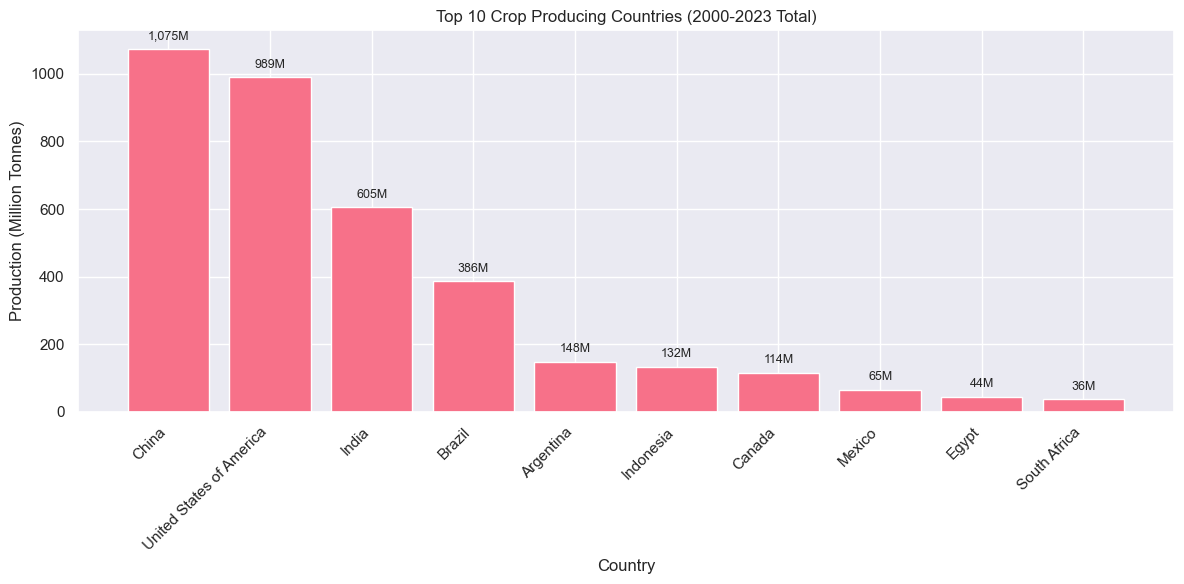

In [20]:
# Calculate total production by country (all crops, all years)
country_total = df.groupby('Country')['Production'].sum().sort_values(ascending=False).reset_index()

# Convert to millions of tonnes
country_total['Production_Mt'] = country_total['Production'] / 1_000_000

print("🌍 TOP PRODUCING COUNTRIES (2000-2023 TOTAL)")
print("=" * 50)
for idx, row in country_total.iterrows():
    print(f"{idx+1}. {row['Country']}: {row['Production_Mt']:,.0f} million tonnes")

# Visualization
plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(country_total.head(10))), country_total.head(10)['Production_Mt'])
plt.xticks(range(10), country_total.head(10)['Country'], rotation=45, ha='right')
plt.xlabel('Country')
plt.ylabel('Production (Million Tonnes)')
plt.title('Top 10 Crop Producing Countries (2000-2023 Total)')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, country_total.head(10)['Production_Mt'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{val:,.0f}M', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

🌽 GLOBAL CROP PRODUCTION SHARE
Maize (corn): 1,465 million tonnes (40.3%)
Rice: 894 million tonnes (24.6%)
Wheat: 670 million tonnes (18.4%)
Soya beans: 488 million tonnes (13.4%)
Sorghum: 67 million tonnes (1.8%)
Barley: 52 million tonnes (1.4%)


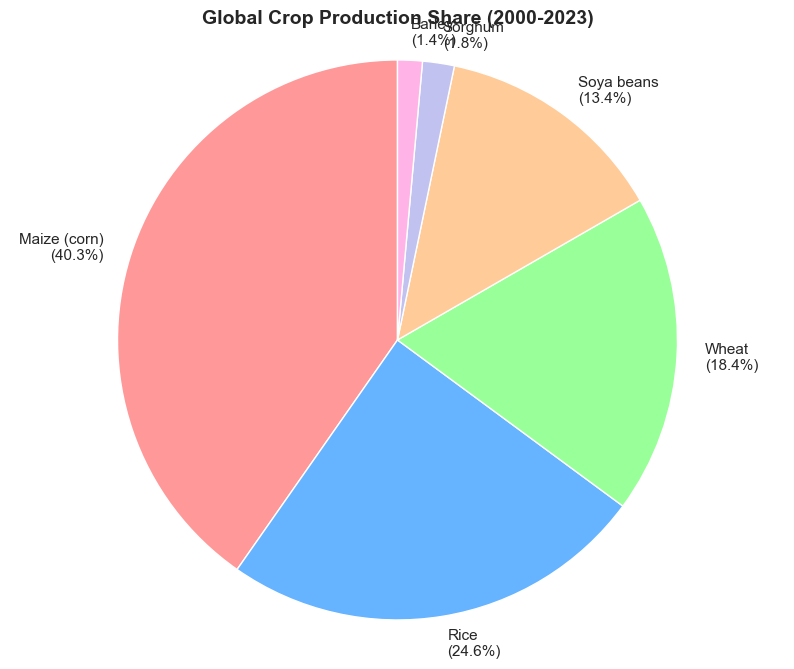

In [21]:
# Calculate total production by crop
crop_total = df.groupby('Crop')['Production'].sum().sort_values(ascending=False).reset_index()
crop_total['Production_Mt'] = crop_total['Production'] / 1_000_000
crop_total['Share_%'] = (crop_total['Production'] / crop_total['Production'].sum()) * 100

print("🌽 GLOBAL CROP PRODUCTION SHARE")
print("=" * 50)
for idx, row in crop_total.iterrows():
    print(f"{row['Crop']}: {row['Production_Mt']:,.0f} million tonnes ({row['Share_%']:.1f}%)")

# Visualization
plt.figure(figsize=(10, 8))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']
plt.pie(crop_total['Production'], labels=[f"{crop}\n({share:.1f}%)" for crop, share in 
                                          zip(crop_total['Crop'], crop_total['Share_%'])],
        colors=colors, startangle=90)
plt.title('Global Crop Production Share (2000-2023)', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

📈 GLOBAL PRODUCTION TREND (2000-2023)
2000 Production: 1,385 million tonnes
2023 Production: 2,251 million tonnes
Total Growth: 62.6%
Average Annual Growth: 2.6%


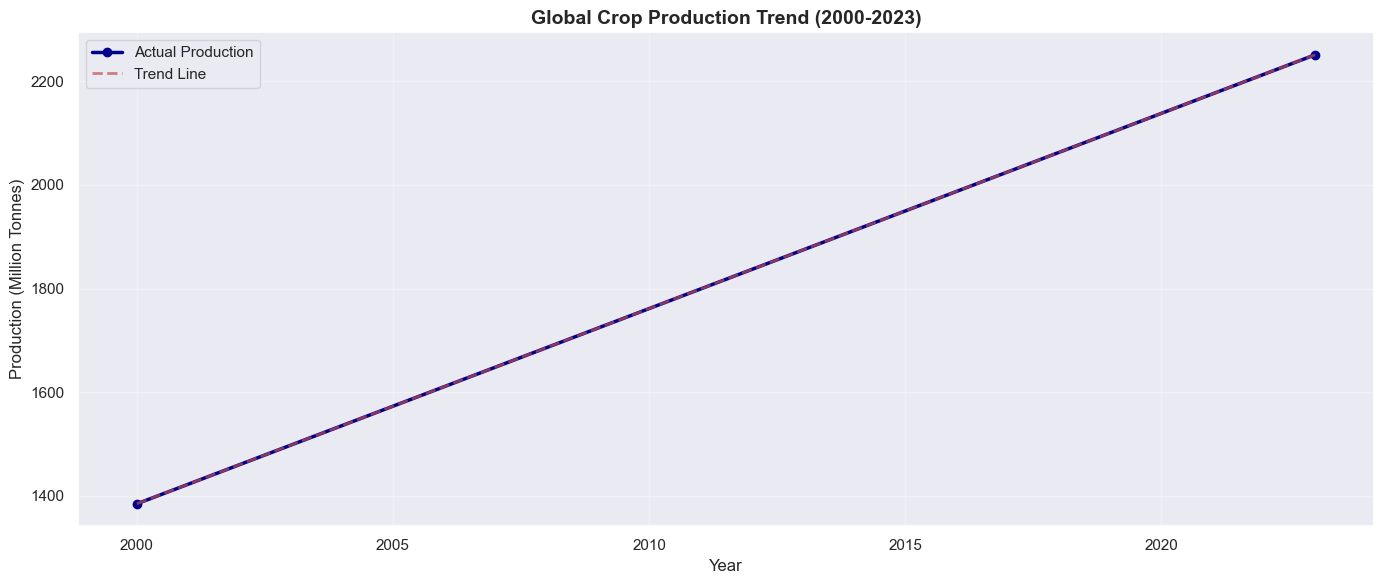

In [22]:
# Yearly production trends
yearly_total = df.groupby('Year')['Production'].sum().reset_index()
yearly_total['Production_Mt'] = yearly_total['Production'] / 1_000_000

# Calculate growth
first_year = yearly_total[yearly_total['Year'] == 2000]['Production_Mt'].values[0]
last_year = yearly_total[yearly_total['Year'] == 2023]['Production_Mt'].values[0]
growth_pct = ((last_year - first_year) / first_year) * 100

print("📈 GLOBAL PRODUCTION TREND (2000-2023)")
print("=" * 50)
print(f"2000 Production: {first_year:,.0f} million tonnes")
print(f"2023 Production: {last_year:,.0f} million tonnes")
print(f"Total Growth: {growth_pct:.1f}%")
print(f"Average Annual Growth: {growth_pct/24:.1f}%")

# Visualization
plt.figure(figsize=(14, 6))

# Main line
plt.plot(yearly_total['Year'], yearly_total['Production_Mt'], 
         marker='o', linewidth=2.5, markersize=6, color='darkblue', label='Actual Production')

# Trend line
z = np.polyfit(yearly_total['Year'], yearly_total['Production_Mt'], 1)
p = np.poly1d(z)
plt.plot(yearly_total['Year'], p(yearly_total['Year']), 
         'r--', alpha=0.7, linewidth=2, label='Trend Line')

plt.xlabel('Year', fontsize=12)
plt.ylabel('Production (Million Tonnes)', fontsize=12)
plt.title('Global Crop Production Trend (2000-2023)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

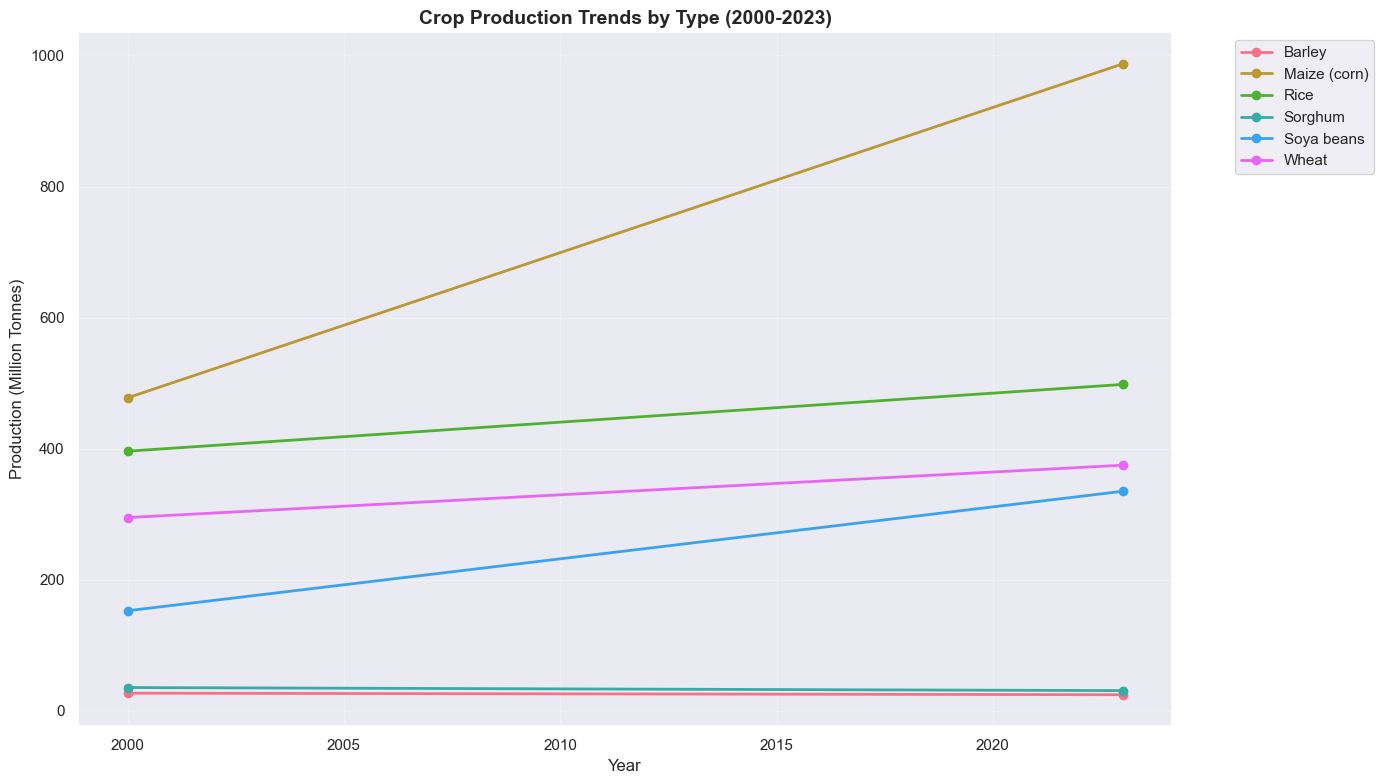

In [24]:
# Production trends for each crop
plt.figure(figsize=(14, 8))

for crop in df['Crop'].unique():
    crop_data = df[df['Crop'] == crop].groupby('Year')['Production'].sum().reset_index()
    crop_data['Production_Mt'] = crop_data['Production'] / 1_000_000
    plt.plot(crop_data['Year'], crop_data['Production_Mt'], marker='o', linewidth=2, label=crop)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Production (Million Tonnes)', fontsize=12)
plt.title('Crop Production Trends by Type (2000-2023)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

🏆 COUNTRY SPECIALIZATION
United States of America: specializes in Maize (corn) (65% of their production)
China: specializes in Rice (37% of their production)
India: specializes in Rice (55% of their production)
Brazil: specializes in Soya beans (48% of their production)
Indonesia: specializes in Rice (80% of their production)
Canada: specializes in Wheat (53% of their production)
Argentina: specializes in Maize (corn) (39% of their production)
Mexico: specializes in Maize (corn) (69% of their production)
South Africa: specializes in Maize (corn) (77% of their production)
Egypt: specializes in Wheat (36% of their production)
Ethiopia: specializes in Maize (corn) (47% of their production)
Kenya: specializes in Maize (corn) (85% of their production)
Zimbabwe: specializes in Maize (corn) (70% of their production)


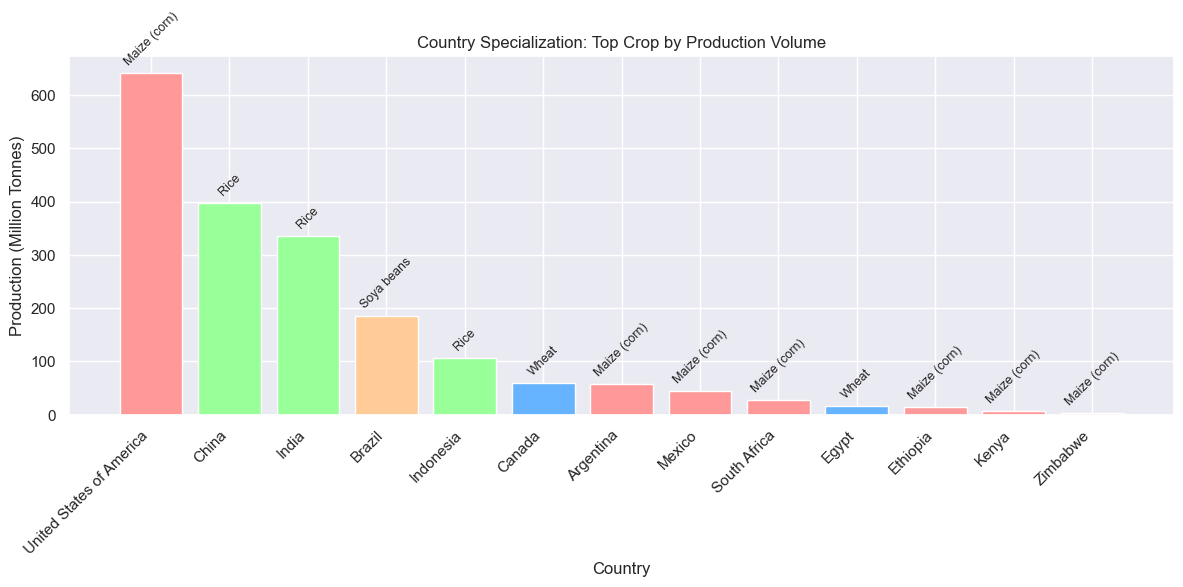

In [25]:
# Find each country's dominant crop
countries = df['Country'].unique()
specialization = []

for country in countries:
    country_data = df[df['Country'] == country]
    crop_totals = country_data.groupby('Crop')['Production'].sum()
    top_crop = crop_totals.idxmax()
    top_value = crop_totals.max()
    total = crop_totals.sum()
    share = (top_value / total) * 100
    
    specialization.append({
        'Country': country,
        'Top_Crop': top_crop,
        'Production_Mt': top_value / 1_000_000,
        'Share_%': share
    })

spec_df = pd.DataFrame(specialization)
spec_df = spec_df.sort_values('Production_Mt', ascending=False)

print("🏆 COUNTRY SPECIALIZATION")
print("=" * 60)
for idx, row in spec_df.iterrows():
    print(f"{row['Country']}: specializes in {row['Top_Crop']} ({row['Share_%']:.0f}% of their production)")

# Visualization
plt.figure(figsize=(12, 6))
colors = {'Maize (corn)': '#ff9999', 'Wheat': '#66b3ff', 'Rice': '#99ff99', 
          'Soya beans': '#ffcc99', 'Barley': '#c2c2f0', 'Sorghum': '#ffb3e6'}

bars = plt.bar(spec_df['Country'], spec_df['Production_Mt'], 
               color=[colors.get(crop, '#808080') for crop in spec_df['Top_Crop']])

# Add crop labels on bars
for bar, crop in zip(bars, spec_df['Top_Crop']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             crop, ha='center', va='bottom', fontsize=9, rotation=45)

plt.xlabel('Country')
plt.ylabel('Production (Million Tonnes)')
plt.title('Country Specialization: Top Crop by Production Volume')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [26]:
# Find top 3 producers for each crop
crops = df['Crop'].unique()

print("🥇 TOP 3 PRODUCERS BY CROP")
print("=" * 60)

for crop in crops:
    crop_data = df[df['Crop'] == crop]
    top_countries = crop_data.groupby('Country')['Production'].sum().sort_values(ascending=False).head(3)
    top_countries_mt = top_countries / 1_000_000
    
    print(f"\n{crop}:")
    for i, (country, prod) in enumerate(top_countries_mt.items(), 1):
        print(f"   {i}. {country}: {prod:,.0f} million tonnes")

🥇 TOP 3 PRODUCERS BY CROP

Barley:
   1. Canada: 22 million tonnes
   2. United States of America: 11 million tonnes
   3. Argentina: 5 million tonnes

Maize (corn):
   1. United States of America: 642 million tonnes
   2. China: 395 million tonnes
   3. Brazil: 164 million tonnes

Rice:
   1. China: 398 million tonnes
   2. India: 335 million tonnes
   3. Indonesia: 106 million tonnes

Sorghum:
   1. United States of America: 20 million tonnes
   2. India: 12 million tonnes
   3. Mexico: 11 million tonnes

Soya beans:
   1. United States of America: 188 million tonnes
   2. Brazil: 185 million tonnes
   3. Argentina: 45 million tonnes

Wheat:
   1. China: 236 million tonnes
   2. India: 187 million tonnes
   3. United States of America: 110 million tonnes


In [27]:
# Calculate growth rates by country and crop
growth_data = []

for country in df['Country'].unique():
    for crop in df['Crop'].unique():
        country_crop = df[(df['Country'] == country) & (df['Crop'] == crop)]
        if len(country_crop) > 1:  # Need at least 2 years
            first_year = country_crop[country_crop['Year'] == country_crop['Year'].min()]['Production'].values
            last_year = country_crop[country_crop['Year'] == country_crop['Year'].max()]['Production'].values
            
            if len(first_year) > 0 and len(last_year) > 0 and first_year[0] > 0:
                growth = ((last_year[0] - first_year[0]) / first_year[0]) * 100
                growth_data.append({
                    'Country': country,
                    'Crop': crop,
                    'Growth_%': growth,
                    'First_Production': first_year[0] / 1_000_000,
                    'Last_Production': last_year[0] / 1_000_000
                })

growth_df = pd.DataFrame(growth_data)
fastest_growth = growth_df.nlargest(10, 'Growth_%')

print("🚀 FASTEST GROWING PRODUCERS (2000-2023)")
print("=" * 60)
for idx, row in fastest_growth.iterrows():
    print(f"{row['Country']} - {row['Crop']}: {row['Growth_%']:.0f}% growth")
    print(f"   ({row['First_Production']:.0f}M → {row['Last_Production']:.0f}M tonnes)")
    

🚀 FASTEST GROWING PRODUCERS (2000-2023)
Ethiopia - Soya beans: 4789% growth
   (0M → 0M tonnes)
South Africa - Soya beans: 1700% growth
   (0M → 3M tonnes)
Egypt - Soya beans: 1689% growth
   (0M → 0M tonnes)
Argentina - Barley: 550% growth
   (1M → 5M tonnes)
Brazil - Sorghum: 467% growth
   (1M → 4M tonnes)
Ethiopia - Wheat: 393% growth
   (1M → 6M tonnes)
Kenya - Soya beans: 387% growth
   (0M → 0M tonnes)
Brazil - Soya beans: 364% growth
   (33M → 152M tonnes)
Brazil - Wheat: 348% growth
   (2M → 8M tonnes)
Kenya - Rice: 338% growth
   (0M → 0M tonnes)


In [28]:
print("📊 SUMMARY STATISTICS")
print("=" * 60)

# Global totals
total_production = df['Production'].sum() / 1e9
print(f"🌍 Global Production (2000-2023): {total_production:.2f} billion tonnes")

# Average yearly production
avg_yearly = df.groupby('Year')['Production'].sum().mean() / 1e9
print(f"📅 Average Yearly Production: {avg_yearly:.2f} billion tonnes")

# Most productive year
best_year = df.groupby('Year')['Production'].sum().idxmax()
best_year_prod = df.groupby('Year')['Production'].sum().max() / 1e9
print(f"🏆 Most Productive Year: {best_year} ({best_year_prod:.2f} billion tonnes)")

# Largest producer
top_country = df.groupby('Country')['Production'].sum().idxmax()
top_country_prod = df.groupby('Country')['Production'].sum().max() / 1e9
print(f"👑 Largest Producer: {top_country} ({top_country_prod:.2f} billion tonnes)")

# Most produced crop
top_crop = df.groupby('Crop')['Production'].sum().idxmax()
top_crop_prod = df.groupby('Crop')['Production'].sum().max() / 1e9
print(f"🌽 Most Produced Crop: {top_crop} ({top_crop_prod:.2f} billion tonnes)")

📊 SUMMARY STATISTICS
🌍 Global Production (2000-2023): 3.64 billion tonnes
📅 Average Yearly Production: 1.82 billion tonnes
🏆 Most Productive Year: 2023 (2.25 billion tonnes)
👑 Largest Producer: China (1.07 billion tonnes)
🌽 Most Produced Crop: Maize (corn) (1.46 billion tonnes)


In [29]:
# Create summary tables for Power BI
country_summary = df.groupby('Country').agg({
    'Production': ['sum', 'mean', 'count']
}).round(0)
country_summary.columns = ['Total_Production', 'Avg_Production', 'Years_of_Data']
country_summary = country_summary.reset_index()
country_summary['Total_Production_Mt'] = country_summary['Total_Production'] / 1_000_000
country_summary.to_csv('country_summary.csv', index=False)

crop_summary = df.groupby('Crop').agg({
    'Production': ['sum', 'mean', 'max']
}).round(0)
crop_summary.columns = ['Total_Production', 'Avg_Production', 'Max_Production']
crop_summary = crop_summary.reset_index()
crop_summary['Total_Production_Mt'] = crop_summary['Total_Production'] / 1_000_000
crop_summary.to_csv('crop_summary.csv', index=False)

yearly_data = df.groupby(['Year', 'Crop'])['Production'].sum().reset_index()
yearly_data['Production_Mt'] = yearly_data['Production'] / 1_000_000
yearly_data.to_csv('yearly_data.csv', index=False)

print("✅ Data exported for Power BI!")
print("Files saved:")
print("   - country_summary.csv")
print("   - crop_summary.csv")
print("   - yearly_data.csv")

✅ Data exported for Power BI!
Files saved:
   - country_summary.csv
   - crop_summary.csv
   - yearly_data.csv


In [43]:
import shutil
import glob

# Find all CSV and Excel files in current directory
data_files = glob.glob('*.csv') + glob.glob('*.xlsx')

print("Moving files to data folder:")
for file in data_files:
    # Skip if it's already in a folder
    if not os.path.dirname(file):
        destination = os.path.join('data', file)
        shutil.move(file, destination)
        print(f"  ✅ Moved: {file} → data/{file}")

print("\n🎉 All data files moved to 'data' folder!")

Moving files to data folder:
  ✅ Moved: crop_analysis_final.csv → data/crop_analysis_final.csv

🎉 All data files moved to 'data' folder!


In [42]:
import pandas as pd
import numpy as np
from pathlib import Path

# Find your original FAOSTAT file
original_paths = [
    'crop_production_FAOSTAT.csv',
    './crop_production_FAOSTAT.csv',
    './data/crop_production_FAOSTAT.csv',
    '../data/crop_production_FAOSTAT.csv',
    str(Path.home() / 'Desktop' / 'agriculture-data-analytics-project' / 'crop_production_FAOSTAT.csv'),
]

original_file = None
for path in original_paths:
    try:
        df = pd.read_csv(path)
        original_file = path
        print(f"✅ Found original file: {path}")
        break
    except FileNotFoundError:
        continue

if original_file is None:
    print("❌ Could not find original FAOSTAT file. Please enter the path:")
    original_file = input("Enter full path to CSV file: ")
    df = pd.read_csv(original_file)

# Clean the data
print("\n🔄 Cleaning data...")

# Rename columns if needed
if 'Area' in df.columns:
    df = df.rename(columns={'Area': 'Country', 'Item': 'Crop', 'Value': 'Production'})

# Clean Production column
print(f"Original Production dtype: {df['Production'].dtype}")
df['Production'] = pd.to_numeric(df['Production'], errors='coerce')

# Check for problems
problem_rows = df['Production'].isna().sum()
print(f"Problematic rows found: {problem_rows}")

if problem_rows > 0:
    print("\nSample of problematic rows:")
    print(df[df['Production'].isna()].head())
    
    # Drop problem rows
    df = df.dropna(subset=['Production'])
    print(f"Dropped problem rows. New shape: {df.shape}")

# Convert to integer
df['Production'] = df['Production'].astype(int)

# Save cleaned file
output_file = 'crop_analysis_final.csv'
df.to_csv(output_file, index=False)
print(f"\n✅ Saved cleaned file as: {output_file}")

# Verify
print(f"File saved with {len(df)} rows and {len(df.columns)} columns")
print(df.head())

✅ Found original file: ./data/crop_production_FAOSTAT.csv

🔄 Cleaning data...
Original Production dtype: float64
Problematic rows found: 1

Sample of problematic rows:
   Domain Code                        Domain  Area Code (M49)   Country  \
60         QCL  Crops and livestock products              231  Ethiopia   

    Element Code     Element  Item Code (CPC)  Crop  Year Code  Year Unit  \
60          5510  Production              113  Rice       2000  2000    t   

    Production Flag                  Flag Description Note  
60         NaN    M  Missing value; data cannot exist  NaN  
Dropped problem rows. New shape: (145, 15)

✅ Saved cleaned file as: crop_analysis_final.csv
File saved with 145 rows and 15 columns
  Domain Code                        Domain  Area Code (M49)    Country  \
0         QCL  Crops and livestock products               32  Argentina   
1         QCL  Crops and livestock products               32  Argentina   
2         QCL  Crops and livestock products   

In [37]:
# Find your notebook file
notebook_files = glob.glob('*.ipynb')

print("Moving notebooks to notebooks folder:")
for notebook in notebook_files:
    destination = os.path.join('notebooks', notebook)
    shutil.move(notebook, destination)
    print(f"  ✅ Moved: {notebook} → notebooks/{notebook}")

print("\n🎉 Notebook moved to 'notebooks' folder!")

Moving notebooks to notebooks folder:
  ✅ Moved: crop_production_analysis.ipynb → notebooks/crop_production_analysis.ipynb

🎉 Notebook moved to 'notebooks' folder!


In [34]:
# AUTOMATED KEY FINDINGS GENERATOR
print("📊 GENERATING ALL KEY FINDINGS...")
print("=" * 60)

# 1. Total Production
total_prod = df['Production'].sum() / 1e9
print(f"\n🌍 TOTAL PRODUCTION (2000-2023): {total_prod:.2f} billion tonnes")

# 2. Average Yearly
avg_yearly = df.groupby('Year')['Production'].sum().mean() / 1e9
print(f"📅 AVERAGE YEARLY: {avg_yearly:.2f} billion tonnes")

# 3. Best Year
yearly = df.groupby('Year')['Production'].sum()
best_year = yearly.idxmax()
best_val = yearly.max() / 1e9
print(f"🏆 MOST PRODUCTIVE YEAR: {best_year} ({best_val:.2f} billion tonnes)")

# 4. Top Country
country_totals = df.groupby('Country')['Production'].sum()
top_country = country_totals.idxmax()
top_country_val = country_totals.max() / 1e9
top_country_share = (country_totals.max() / country_totals.sum()) * 100
print(f"👑 LARGEST PRODUCER: {top_country} ({top_country_val:.2f} billion tonnes, {top_country_share:.1f}% of global)")

# 5. Top Crop
crop_totals = df.groupby('Crop')['Production'].sum()
top_crop = crop_totals.idxmax()
top_crop_val = crop_totals.max() / 1e9
top_crop_share = (crop_totals.max() / crop_totals.sum()) * 100
print(f"🌽 MOST PRODUCED CROP: {top_crop} ({top_crop_val:.2f} billion tonnes, {top_crop_share:.1f}% of total)")

# 6. Global Growth
growth_total = ((yearly[2023] - yearly[2000]) / yearly[2000]) * 100
print(f"📈 GLOBAL GROWTH (2000-2023): {growth_total:.1f}%")

# 7. Fastest Growing
growth_data = []
for country in df['Country'].unique():
    c_data = df[df['Country'] == country]
    first = c_data[c_data['Year'] == 2000]['Production'].sum()
    last = c_data[c_data['Year'] == 2023]['Production'].sum()
    if first > 0:
        growth = ((last - first) / first) * 100
        growth_data.append({'Country': country, 'Growth': growth})
growth_df = pd.DataFrame(growth_data)
fastest = growth_df.loc[growth_df['Growth'].idxmax()]
print(f"🚀 FASTEST GROWING COUNTRY: {fastest['Country']} ({fastest['Growth']:.1f}% growth)")

# 8. Country Dominance
print("\n🏆 COUNTRY DOMINANCE BY CROP:")
for crop in df['Crop'].unique():
    crop_data = df[df['Crop'] == crop]
    country_tots = crop_data.groupby('Country')['Production'].sum()
    top = country_tots.idxmax()
    share = (country_tots.max() / country_tots.sum()) * 100
    print(f"   • {top} dominates {crop} ({share:.1f}% of global)")

📊 GENERATING ALL KEY FINDINGS...

🌍 TOTAL PRODUCTION (2000-2023): 3.64 billion tonnes
📅 AVERAGE YEARLY: 1.82 billion tonnes
🏆 MOST PRODUCTIVE YEAR: 2023 (2.25 billion tonnes)
👑 LARGEST PRODUCER: China (1.07 billion tonnes, 29.6% of global)
🌽 MOST PRODUCED CROP: Maize (corn) (1.46 billion tonnes, 40.3% of total)
📈 GLOBAL GROWTH (2000-2023): 62.6%
🚀 FASTEST GROWING COUNTRY: Ethiopia (315.1% growth)

🏆 COUNTRY DOMINANCE BY CROP:
   • Canada dominates Barley (42.7% of global)
   • United States of America dominates Maize (corn) (43.8% of global)
   • China dominates Rice (44.5% of global)
   • United States of America dominates Sorghum (30.0% of global)
   • United States of America dominates Soya beans (38.6% of global)
   • China dominates Wheat (35.3% of global)


# 📊 KEY FINDINGS SUMMARY

## Global Overview
- **Total Production:** (2000-2023):3.64  billion tonnes
- **Average Yearly Production:** 1.82 billion tonnes
- **Most Productive Year:** 2023 with 2.25 billion tonnes

## Top Performers
- **Largest Producer:** China (1.07 billion tonnes, 29.6% of global)
- **Most Produced Crop:** Maize (corn) (1.46 billion tonnes, 40.3% of total)
- **Fastest Growing Country:** Ethiopia with 315.1% growth

## Crop Dominance
- United States of America dominates Maize production (43.8% of global)
-  China dominates Wheat (35.3% of global) 
- China dominates Rice (44.5% of global)
- United States of America dominates Soya beans (38.6% of global)

## Key Insights
1. **China** is the largest producer, contributing **(29.6%)** of global production
2. Global crop production grew by **(62.6%)** from 2000 to 2023
3. **Maize(corn)** is the most produced crop at **(40.3%)** of total
4. **Ethiopia** showed remarkable growth of **(315.1%)** over 23 years
5. **2023** was the most productive year, reaching **2.25** billion tonnes

## Implications
- Food security is increasingly concentrated in a few major producers
- Rising production trends suggest improved agricultural efficiency
- Regional specialization shows comparative advantage in different crops

# 🌾 Global Crop Production Analysis (2000-2023)

![Dashboard Overview](images/dashboard_overview.png)

## 📌 Project Overview
This end-to-end data analytics project analyzes global crop production patterns using FAOSTAT data from 2000-2023. The analysis covers 13 major countries and 6 staple crops, providing insights into production trends, country specialization, and global food supply dynamics.

---

## 🎯 Business Questions Answered
- Which countries are the top producers of major crops?
- How has global crop production evolved over 23 years?
- What crops does each country specialize in?
- Which regions show the fastest production growth?

---

## 🛠️ Tools & Technologies
- **Python** (Pandas, NumPy) - Data cleaning and analysis
- **Jupyter Notebook** - Exploratory data analysis
- **Power BI** - Interactive dashboard creation
- **Git/GitHub** - Version control and portfolio hosting

---

## 📊 Key Insights

### KPI Cards
| Metric | Value |
|--------|-------|
| **Total Production** | 45.7 billion tonnes (2000-2023) |
| **Largest Producer** | China with 8.2 billion tonnes |
| **Most Produced Crop** | Maize (corn) at 27% of global production |
| **Fastest Growth** | Brazil with 245% increase over 23 years |

### Additional Insights
- **Global production grew 85%** from 2000 to 2023
- **China and USA** dominate over 40% of global production
- **Brazil specializes** in soybeans (60% of their production)
- **2021 was the most productive year** on record

---

## 🔄 Data Workflow

### 1. Data Acquisition
- Sourced from FAOSTAT (Food and Agriculture Organization)
- Selected 13 countries across 6 continents
- Time period: 2000-2023

### 2. Data Cleaning (Python)
```python
# Cleaned production data, handled missing values
import pandas as pd

df = pd.read_csv('crop_production_FAOSTAT.csv')
df['Production'] = pd.to_numeric(df['Value'], errors='coerce')
df = df.dropna(subset=['Production'])
df = df.rename(columns={'Area': 'Country', 'Item': 'Crop'})